### Install Required Libraries IoT Crop Disease Detection

### Mount Google Drive

In [ ]:
from google.colab import drive # type: ignore
drive.mount('/content/drive')

Mounted at /content/drive


### Check GPU

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


###  Extract the dataset

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/dataset/Crop_Disease_Split/train"))
print(os.path.exists("/content/drive/MyDrive/dataset/Crop_Disease_Split/valid"))
print(os.path.exists("/content/drive/MyDrive/dataset/Crop_Disease_Split/test"))

✅ Dataset extracted successfully!


### Import libraries

In [ ]:
import torch
from torchvision import datasets, transforms  # type: ignore
from torch.utils.data import DataLoader, random_split

###  Load the dataset

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

DATASET_PATH = "/content/dataset/Crop_Disease_Image_Dataset"

full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

print("Total Images:", len(full_dataset))
print("Total Classes:", len(full_dataset.classes))
print(full_dataset.classes)

Total Images: 22169
Total Classes: 19
['Corn_(Maize)___Common_Rust', 'Corn_(Maize)___Gray_Leaf_Spot_(Cercospora)', 'Corn_(Maize)___Healthy', 'Corn_(Maize)___Leaf_Spot', 'Corn_(Maize)___Maize_Streak_Virus', 'Corn_(Maize)___Northern_Leaf_Blight', 'Potato___Early_Blight', 'Potato___Healthy', 'Potato___Late_Blight', 'Rice___Brown_Spot', 'Rice___Healthy', 'Rice___Leaf_Blast', 'Tomato___Bacterial_Spot', 'Tomato___Early_Blight', 'Tomato___Healthy', 'Tomato___Late_Blight', 'Wheat___Brown_Rust', 'Wheat___Healthy', 'Wheat___Yellow_Rust']


In [ ]:
print(os.path.exists("/content/drive/MyDrive/dataset/Crop_Disease_Split/train"))
print(os.path.exists("/content/drive/MyDrive/dataset/Crop_Disease_Split/valid"))
print(os.path.exists("/content/drive/MyDrive/dataset/Crop_Disease_Split/test"))

In [ ]:
train_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/dataset/Crop_Disease_Split/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/dataset/Crop_Disease_Split/valid",
    transform=valid_transform
)

test_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/dataset/Crop_Disease_Split/test",
    transform=valid_transform
)

#### Create train_transform

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
# Use train_transform in dataset 


from torchvision import datasets

train_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/dataset/Crop_Disease_Split/train",
    transform=train_transform
)

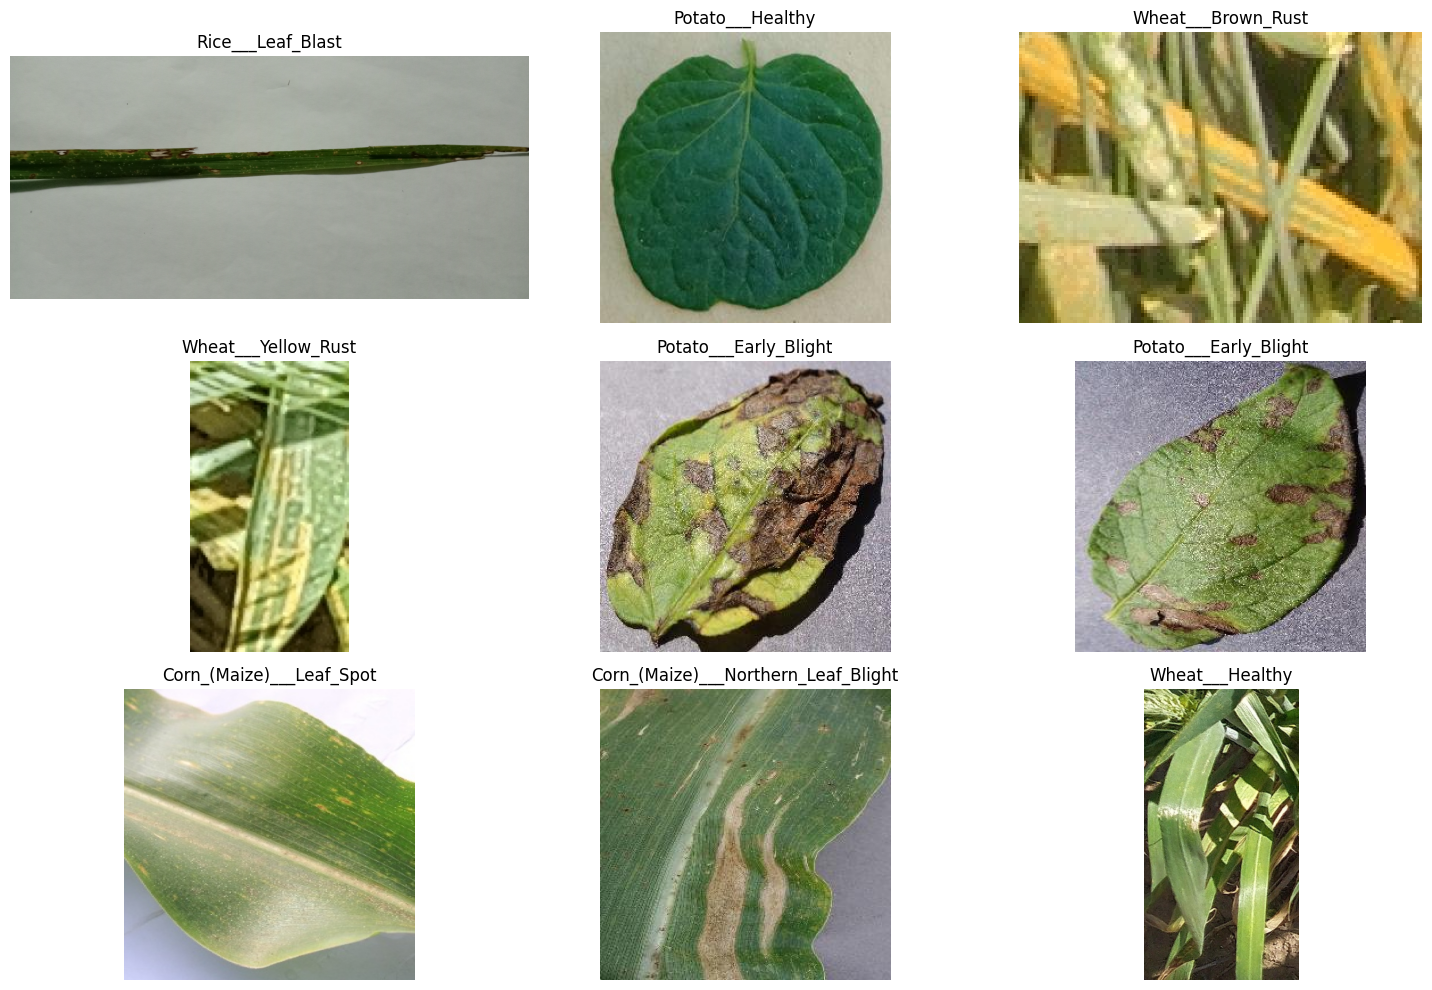

In [6]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/content/dataset/Crop_Disease_Image_Dataset"

classes = os.listdir(dataset_path)

plt.figure(figsize=(15, 10))

for i in range(9):
    cls = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))

    img = Image.open(os.path.join(dataset_path, cls, img_name))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import os
from collections import Counter

dataset_path = "/content/dataset/Crop_Disease_Split/train"

sizes = Counter()

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(root, file)

            with Image.open(img_path) as img:
                sizes[img.size] += 1

print("Image Dimensions Found:\n")

for size, count in sizes.items():
    print(f"{size} : {count} images")

Image Dimensions Found:



In [8]:
import os

dataset_path = "/content/dataset/Crop_Disease_Split/train"

print(os.path.exists(dataset_path))
print(os.listdir(dataset_path)[:5])

False


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/Crop_Disease_Split/train'

In [10]:
from PIL import Image
import os
from collections import Counter

dataset_path = "/content/dataset/Crop_Disease_Image_Dataset"

sizes = Counter()
total_images = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(root, file)

            try:
                with Image.open(img_path) as img:
                    sizes[img.size] += 1
                    total_images += 1
            except Exception as e:
                print(f"Error reading: {img_path}")

print(f"\nTotal Images: {total_images}")
print("\nImage Dimensions Found:\n")

for size, count in sorted(sizes.items()):
    print(f"{size[0]} x {size[1]} : {count} images")


Total Images: 22169

Image Dimensions Found:

16 x 60 : 1 images
18 x 52 : 1 images
18 x 72 : 1 images
18 x 228 : 1 images
24 x 88 : 1 images
24 x 229 : 1 images
25 x 164 : 1 images
27 x 72 : 1 images
27 x 162 : 1 images
30 x 1 : 1 images
30 x 143 : 1 images
30 x 166 : 1 images
30 x 192 : 1 images
30 x 195 : 1 images
30 x 268 : 1 images
31 x 109 : 1 images
32 x 158 : 1 images
32 x 268 : 1 images
33 x 78 : 1 images
34 x 48 : 1 images
34 x 128 : 1 images
35 x 114 : 1 images
36 x 156 : 1 images
36 x 196 : 1 images
36 x 215 : 1 images
37 x 96 : 1 images
39 x 95 : 1 images
39 x 169 : 1 images
39 x 249 : 1 images
39 x 312 : 1 images
40 x 54 : 1 images
40 x 146 : 1 images
40 x 199 : 1 images
41 x 110 : 1 images
41 x 126 : 1 images
41 x 140 : 1 images
41 x 263 : 1 images
41 x 269 : 1 images
42 x 24 : 1 images
42 x 96 : 1 images
42 x 106 : 1 images
42 x 130 : 1 images
42 x 149 : 1 images
42 x 192 : 1 images
42 x 214 : 1 images
42 x 240 : 1 images
44 x 105 : 1 images
44 x 158 : 1 images
44 x 16

In [11]:
from PIL import Image
import os

dataset_path = "/content/dataset/Crop_Disease_Image_Dataset"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(root, file)

            try:
                with Image.open(img_path) as img:
                    w, h = img.size

                    if w < 100 or h < 100:
                        print(f"{img_path} --> {w} x {h}")
            except:
                pass

/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust379.jpg --> 92 x 142
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust109.jpg --> 338 x 70
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust1026.jpg --> 99 x 272
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust257.jpg --> 362 x 56
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust794.jpg --> 94 x 298
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust728.jpg --> 108 x 96
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust666.jpg --> 88 x 290
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust849.jpg --> 184 x 62
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust934.jpg --> 180 x 72
/content/dataset/Crop_Disease_Image_Dataset/Wheat___Yellow_Rust/Yellow_rust540.jpg --> 84 x 202
/content/dataset/Crop_Disease_Image_Dat